# Głębokie sieci neuronowe z rozgałęzieniami
[![](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/piotrsok2/cv-course/blob/pytorch/exercises/03_deeperCNN.ipynb)


In [2]:
import os

# Ustawienie PyTorch jako zaplecza dla biblioteki Keras
os.environ["KERAS_BACKEND"] = "torch"

# PyTorch i keras
import torch
import keras
from keras import datasets, callbacks, layers, models, optimizers, losses

import numpy as np
import matplotlib.pyplot as plt

# Sprawdzenie dostępności GPU
#print(tf.config.list_physical_devices('GPU'))
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    if torch.xpu.is_available():
        for i in range(torch.xpu.device_count()):
            print(f"XPU {i}: {torch.xpu.get_device_name(i)}")
    else:
        print("Brak dostępnych GPU lub XPU.")
        print("Używam CPU.")

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


GPU 0: AMD Radeon Graphics


/home/psokolow/.local/lib/python3.14/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Przygotowanie zestawu danych CIFAR10
Przykłady w tym zbiorze mają format 32 na 32 punkty i są kolorowe, a więc posiadają trzy kanały.

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


### Weryfikacja przykładów

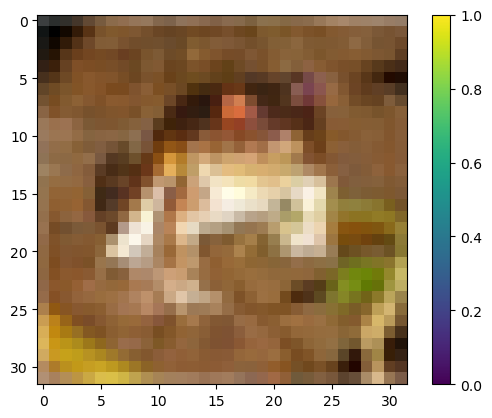

(32, 32, 3)


In [4]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

input_shape = train_images[0].shape
if len(input_shape) < 3:
    input_shape += tuple([1])
print(input_shape)

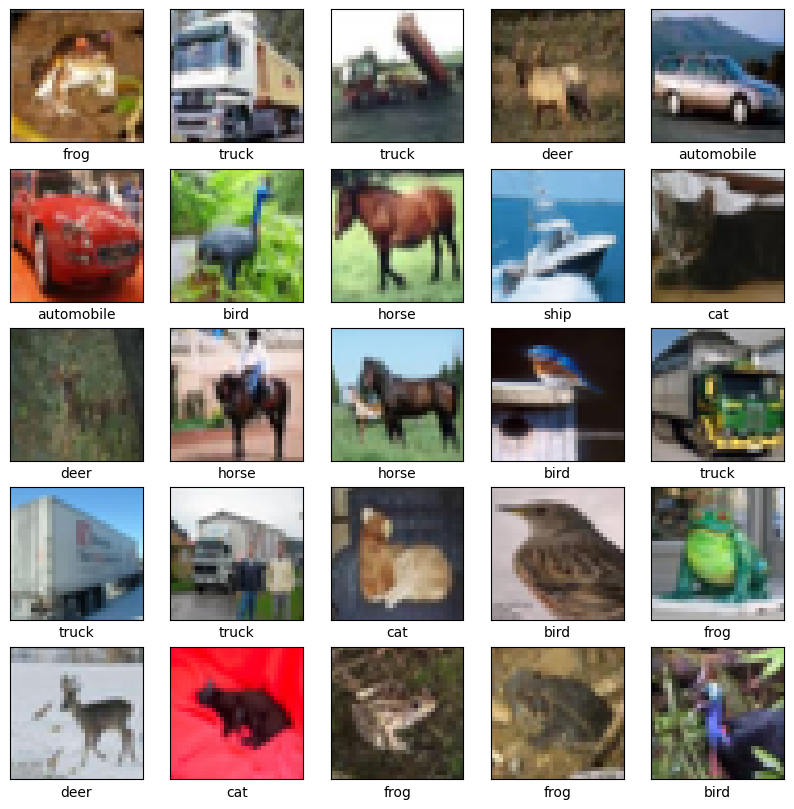

10

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()
len(class_names)

### Wstępne przetważanie

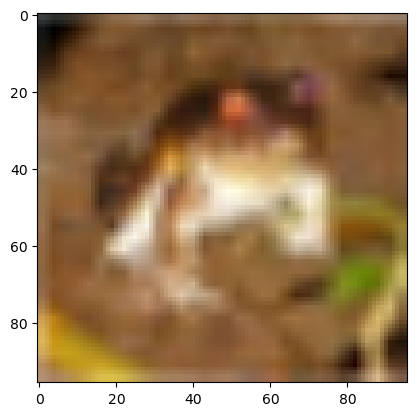

In [6]:
IMG_SIZE = 96
input_resize = layers.Resizing(IMG_SIZE, IMG_SIZE)

plt.imshow(input_resize(train_images[0]).cpu()) # .cpu() - aby przenieść tensor PyTorch na CPU

## Blok z obejściem

In [7]:
class Residual(keras.Model):  #@save
    """The Residual block of ResNet models."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = layers.Conv2D(num_channels, padding='same',
                                            kernel_size=3, strides=strides)
        self.conv2 = layers.Conv2D(num_channels, kernel_size=3,
                                            padding='same')
        self.conv3 = None
        if use_1x1conv:
            self.conv3 = layers.Conv2D(num_channels, kernel_size=1,
                                                strides=strides)
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()

    def call(self, X):
        Y = keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3 is not None:
            X = self.conv3(X)
        Y += X
        return keras.activations.relu(Y)

### ResNet-18

In [8]:
def b1():
    return  models.Sequential([
            layers.Conv2D(64, kernel_size=7, strides=2,
                                   padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D(pool_size=3, strides=2,
                                      padding='same')])

def resnet_module(num_residuals, num_channels, first_block=False):
    blk = models.Sequential()
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.add(Residual(num_channels, use_1x1conv=True, strides=2))
        else:
            blk.add(Residual(num_channels))
    return blk

def resnet(arch, classifier_input, num_classes):
    net = models.Sequential([
        keras.Input(shape=classifier_input),
        input_resize,
        b1()
    ])
    
    for i, b in enumerate(arch):
        net.add(resnet_module(*b, first_block=(i==0)))
        
    net.add(models.Sequential([
        layers.GlobalAvgPool2D(),
        layers.Dense(units=num_classes)]
    ))
    return net

def resnet_18(classifier_input, num_classes):
    return resnet(((2, 64), (2, 128), (2, 256), (2, 512)),
                       classifier_input, num_classes)


### Wybór modelu

In [9]:
model = resnet_18(input_shape, len(class_names))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 24, 24, 64)     │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 24, 24, 64)     │       148,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 12, 12, 128)    │       526,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 6, 6, 256)      │     2,102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 3, 3, 512)      │     8,399,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,192,458 (42.70 MB)

 Trainable params: 11,184,650 (42.67 MB)

 Non-trainable params: 7,808 (30.50 KB)

### Skład i trening modelu

In [ ]:

model.compile(optimizer=optimizers.SGD(learning_rate = 0.1, momentum = 0.9, weight_decay = 0.0001),
              loss=losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels),
                    batch_size=128
                    )

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 93s 155ms/step - accuracy: 0.5166 - loss: 1.3442 - val_accuracy: 0.1814 - val_loss: 3.1315
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.6782 - loss: 0.9052 - val_accuracy: 0.4765 - val_loss: 1.6446
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.7775 - loss: 0.6341 - val_accuracy: 0.6234 - val_loss: 1.1189
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 144ms/step - accuracy: 0.8598 - loss: 0.4029 - val_accuracy: 0.5324 - val_loss: 1.9461
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 155ms/step - accuracy: 0.9190 - loss: 0.2352 - val_accuracy: 0.6231 - val_loss: 1.4784
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.9494 - loss: 0.1465 - val_accuracy: 0.6297 - val_loss: 1.6250
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - accuracy: 0.9602 - loss: 0.1148 - val_accuracy: 0.6397 - val_loss: 1.5728
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - accuracy: 0.9661 - loss: 0

### Wyniki

313/313 - 11s - 34ms/step - accuracy: 0.6685 - loss: 1.6057


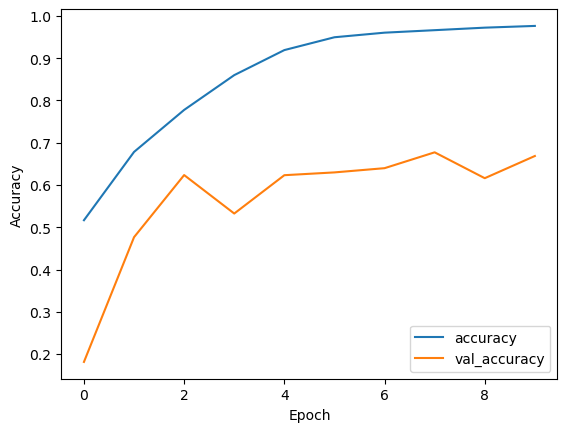

In [11]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
#plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
print(test_acc)

# Zadania
1.  Przetestuj warianty sieci ResNet, opisane w sekcji 4.2 z poniższego artykułu: https://doi.org/10.1109/CVPR.2016.90. (2 pkt)
1. Na sieci z poprzedniego zadania zastosuj przewężenia (ang. bottleneck). (2 pkt)
1. W kolejnych udoskonaleniach autorzy zmieniają schemat "splot, normalizacja wsadu i aktywacja" na "normalizacja wsadu, aktywacja i splot". Dodaj to usprawnienie. Jako wzór możesz wykorzystać rysunek 1 z artykułu: https://doi.org/10.1007/978-3-319-46493-0_38 (1 pkt)